# Détecteur de fraude - Résultats

## Objectifs

* Monitoring des prédiction (Base SQLite & Notebook)

In [24]:
# Import modules
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [46]:
# Connexion à la base locale 
path = r"D:\Profils\NLefort\Desktop\JEDHA\PROJETS LEAD\Detecteur_fraude\data\fraud_predictions.db"
conn = sqlite3.connect(path)

# Lecture des données
df = pd.read_sql("SELECT * FROM transactions", conn)
conn.close()

dataset = df.copy()

In [47]:
## Analyse descriptive
# INFORMATIONS GENERALES
print("\n INFORMATIONS GENERALES")
print("-" * 40)

print("Nombre de lignes (nb de transactions): {}".format(dataset.shape[0]))
print("Nombre de colonnes : {}".format(dataset.shape[1]))
print("Nombre de fraudes : {}".format(dataset["is_fraud"].sum()))

print("Aperçu du dataset : ")
display(dataset.head())

print("Types de données/colonnes : ")
display(dataset.dtypes)


 INFORMATIONS GENERALES
----------------------------------------
Nombre de lignes (nb de transactions): 16
Nombre de colonnes : 26
Nombre de fraudes : 0
Aperçu du dataset : 


,cc_num,merchant,category,amt,first,last,gender,street,city,state,...,trans_num,merch_lat,merch_long,is_fraud,current_time,distance_km,Hour,Weekday,gender_m,category_enc
0,4306586894261180,fraud_Dibbert and Sons,entertainment,225.25,Renee,Walls,F,86542 Jessica Fords Apt. 706,Veedersburg,IN,...,088130e4c552245a76fcd7a890d8a3aa,40.746622,-87.837832,0,1770907907660,85.245221,14,3,0,0.001402
1,2248735346244816,fraud_Dickinson-Rempel,misc_pos,65.56,Jacob,Weber,M,29156 Mark Park Apt. 108,Utica,KS,...,a3bb972bddae63ed014920d22a41799f,38.252926,-99.268436,0,1770908118921,87.163623,14,3,1,0.002170
2,4358137750029944984,"fraud_Baumbach, Hodkiewicz and Walsh",shopping_pos,1.85,Dawn,Stephens,F,91542 Marissa Shores Apt. 053,Oran,IA,...,d26f4fb041ce0fb0d4ebcc89ca33bc0a,43.367513,-92.215430,0,1770908418006,74.949802,15,3,0,0.004353
3,4426075337087318654,"fraud_Reinger, Weissnat and Strosin",food_dining,1.57,Kyle,James,M,621 Smith Hollow Apt. 738,Topeka,KS,...,43cc80ff334fecaa870289be9a0c6fe0,38.175965,-95.724203,0,1770908718417,99.062738,15,3,1,0.001366
4,4358137750029944984,fraud_Dicki Ltd,grocery_net,64.16,Dawn,Stephens,F,91542 Marissa Shores Apt. 053,Oran,IA,...,246105d1aba4edad792bdec689198ca0,42.601492,-91.279210,0,1770909017448,66.116010,15,3,0,0.002128


Types de données/colonnes : 


cc_num            int64
merchant         object
category         object
amt             float64
first            object
last             object
gender           object
street           object
city             object
state            object
zip               int64
lat             float64
long            float64
city_pop          int64
job              object
dob              object
trans_num        object
merch_lat       float64
merch_long      float64
is_fraud          int64
current_time      int64
distance_km     float64
Hour              int64
Weekday           int64
gender_m          int64
category_enc    float64
dtype: object

In [48]:
# STATISTIQUES DESCRIPTIVES
# Statistiques descriptives globales
print("Statistiques descriptives globales :")
display(dataset.describe(include="all").round(2))

Statistiques descriptives globales :


,cc_num,merchant,category,amt,first,last,gender,street,city,state,...,trans_num,merch_lat,merch_long,is_fraud,current_time,distance_km,Hour,Weekday,gender_m,category_enc
count,1.600000e+01,16,16,16.00,16,16,16,16,16,16,...,16,16.00,16.00,16.0,1.600000e+01,16.00,16.00,16.0,16.00,16.00
unique,NaN,15,9,NaN,15,14,2,15,15,10,...,16,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,"fraud_Welch, Rath and Koepp",entertainment,NaN,Dawn,Weber,F,91542 Marissa Shores Apt. 053,Oran,NY,...,088130e4c552245a76fcd7a890d8a3aa,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,2,4,NaN,2,2,10,2,2,3,...,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,1.123241e+18,NaN,NaN,123.82,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,40.44,-88.03,0.0,1.770910e+12,80.70,15.00,3.0,0.38,0.00
std,2.008887e+18,NaN,NaN,229.53,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,3.96,10.95,0.0,1.419344e+06,26.27,0.52,0.0,0.50,0.00
min,6.304515e+11,NaN,NaN,1.57,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,29.89,-115.67,0.0,1.770908e+12,28.14,14.00,3.0,0.00,0.00
25%,2.397413e+13,NaN,NaN,4.40,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,38.23,-92.85,0.0,1.770909e+12,66.09,15.00,3.0,0.00,0.00
50%,2.877664e+15,NaN,NaN,70.00,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,40.39,-89.47,0.0,1.770910e+12,86.20,15.00,3.0,0.00,0.00
75%,1.092764e+18,NaN,NaN,98.16,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,43.46,-78.42,0.0,1.770911e+12,99.40,15.00,3.0,1.00,0.00


In [49]:
# VALEURS MANQUANTES
print("\n VALEURS MANQUANTES")
print("-" * 40)

print("Nombre de valeurs manquantes par colonne :")
missing_values = dataset.isnull().sum()
missing_values_percentage = ((missing_values / dataset.shape[0]) * 100).round(
    2
)
missing_df = pd.DataFrame(
    {
        "Valeurs manquantes": missing_values,
        "Pourcentage": missing_values_percentage,
    }
)
print(missing_df[missing_df["Valeurs manquantes"] > 0])

# CONVERSION VALEURS NUMERIQUES
# Convertir la colonne en format datetime
dataset["current_time"] = pd.to_datetime(dataset["current_time"])

# Convertir Date en année / semaine / jour de semaine
dataset["Year"] = dataset["current_time"].dt.year
dataset["Month"] = dataset["current_time"].dt.month
dataset["Day"] = dataset["current_time"].dt.day
dataset["Weekday"] = dataset["current_time"].dt.weekday  # 0 = Lundi, 6 = Dimanche
dataset['Hour'] = dataset['current_time'].dt.hour



 VALEURS MANQUANTES
----------------------------------------
Nombre de valeurs manquantes par colonne :
Empty DataFrame
Columns: [Valeurs manquantes, Pourcentage]
Index: []


c:\Users\NLefort\AppData\Local\anaconda3\Lib\site-packages\pandas\plotting\_matplotlib\core.py:1567: UserWarning: Attempting to set identical low and high xlims makes transformation singular; automatically expanding.
  ax.set_xlim(left, right)


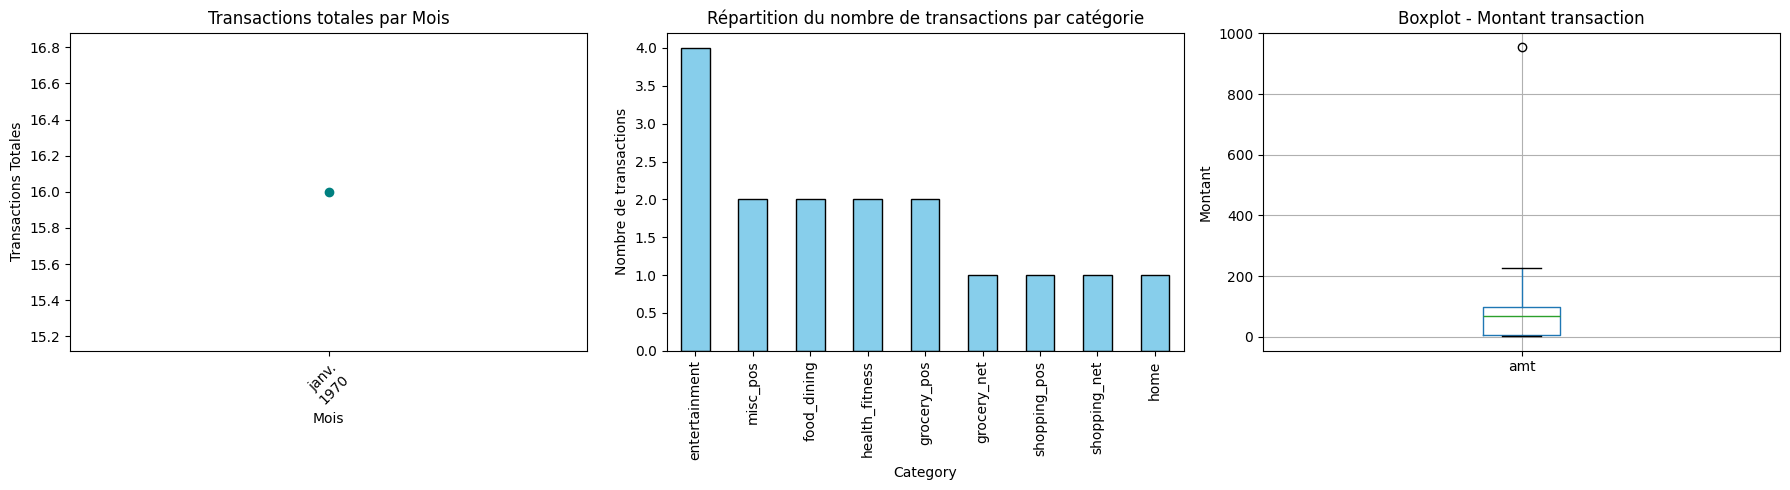

In [50]:
# DESCRIPTION DES VARIABLES
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Variable "ventes_par_mois"
dataset['Month_Year'] = dataset['current_time'].dt.to_period('M')
trans_par_mois = dataset.groupby('Month_Year').size()
ax = trans_par_mois.plot(kind="line", marker='o', linestyle='-', color='teal', linewidth=2, ax=axes[0])

axes[0].set_title("Transactions totales par Mois")
axes[0].set_xlabel("Mois")
axes[0].set_ylabel("Transactions Totales")
axes[0].tick_params(axis="x", rotation=45)

# Variable "category"
# Calculer la fréquence par catégorie
cat_freq = dataset["category"].value_counts()
ax = cat_freq.plot(kind="bar", color="skyblue", edgecolor="black", ax=axes[1])

axes[1].set_title("Répartition du nombre de transactions par catégorie")
axes[1].set_xlabel("Category")
axes[1].set_ylabel("Nombre de transactions")

# Boxplot - "amt"
dataset.boxplot(column="amt", ax=axes[2])
axes[2].set_title("Boxplot - Montant transaction")
axes[2].set_ylabel("Montant")

plt.tight_layout()
plt.show()